In [1]:
# ============================================================
# CELL 1: INSTALL LIBRARIES
# Run this first — only needed once
# ============================================================

# If running on Google Colab, uncomment these:
# !pip install xgboost shap -q

# Core libraries — these come pre-installed everywhere
import numpy as np           # Math operations
import pandas as pd          # Data tables (like Excel)
import matplotlib.pyplot as plt  # Plotting graphs
import seaborn as sns        # Beautiful graphs


import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
# (This means every time you run, same results)
np.random.seed(42)

# Make graphs look beautiful
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries loaded successfully!")
print(f"   NumPy version:      {np.__version__}")
print(f"   Pandas version:     {pd.__version__}")
print(f"   Matplotlib version: {plt.matplotlib.__version__}")
print("\n🚀 Ready to start!")

✅ All libraries loaded successfully!
   NumPy version:      2.4.3
   Pandas version:     2.3.3
   Matplotlib version: 3.10.8

🚀 Ready to start!


In [2]:
# ============================================================
# CELL 2: DEFINE FEATURES WE ARE USING
# These are the SAME features this paper used!
# ============================================================

# Feature groups — same as in the paper
FEATURE_GROUPS = {
    
    'Gaze Features': [
        'gaze_x_mean',      # Where eyes look horizontally (left/right)
        'gaze_y_mean',      # Where eyes look vertically (up/down)
        'gaze_x_std',       # How much horizontal gaze varies
        'gaze_y_std',       # How much vertical gaze varies
        'gaze_angle_mean',  # Overall angle of gaze
        'gaze_angle_std',   # How much gaze angle changes
    ],
    
    'Eye Features': [
        'blink_rate',        # Blinks per minute (normal=15-20)
        'eye_open_mean',     # How open the eyes are on average
        'eye_open_std',      # Variation in eye openness
        'pupil_x_mean',      # Pupil horizontal position
        'pupil_y_mean',      # Pupil vertical position
        'pupil_movement',    # How much pupil moves
    ],
    
    'Head Pose Features': [
        'head_pitch_mean',   # Head tilt up/down
        'head_yaw_mean',     # Head turn left/right
        'head_roll_mean',    # Head tilt sideways
        'head_movement',     # Overall head movement amount
    ],
    
    'Action Unit Features': [
        'AU01_mean',   # Inner brow raise
        'AU04_mean',   # Brow lowerer (frowning)
        'AU06_mean',   # Cheek raiser (genuine smile)
        'AU07_mean',   # Lid tightener
        'AU12_mean',   # Lip corner puller (smile)
        'AU15_mean',   # Lip corner depressor (sadness)
        'AU17_mean',   # Chin raiser
        'AU45_mean',   # Blink
    ],
    
    'Temporal Features': [
        'gaze_stability',    # How stable gaze is over time
        'expression_change', # How much expression changes
        'micro_expressions', # Tiny brief expressions count
    ]
}

# Get all feature names as a flat list
ALL_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]

print("📊 FEATURES WE ARE USING:")
print("=" * 50)
total = 0
for group_name, features in FEATURE_GROUPS.items():
    print(f"\n{group_name} ({len(features)} features):")
    for f in features:
        print(f"   • {f}")
    total += len(features)
print(f"\n{'='*50}")
print(f"Total features: {total}")
print(f"\n💡 Note: The original paper used 8,508 features!")
print(f"   We use {total} most important ones for clarity.")

📊 FEATURES WE ARE USING:

Gaze Features (6 features):
   • gaze_x_mean
   • gaze_y_mean
   • gaze_x_std
   • gaze_y_std
   • gaze_angle_mean
   • gaze_angle_std

Eye Features (6 features):
   • blink_rate
   • eye_open_mean
   • eye_open_std
   • pupil_x_mean
   • pupil_y_mean
   • pupil_movement

Head Pose Features (4 features):
   • head_pitch_mean
   • head_yaw_mean
   • head_roll_mean
   • head_movement

Action Unit Features (8 features):
   • AU01_mean
   • AU04_mean
   • AU06_mean
   • AU07_mean
   • AU12_mean
   • AU15_mean
   • AU17_mean
   • AU45_mean

Temporal Features (3 features):
   • gaze_stability
   • expression_change
   • micro_expressions

Total features: 27

💡 Note: The original paper used 8,508 features!
   We use 27 most important ones for clarity.


In [3]:
# ============================================================
# CELL 3: LOAD IMAGE DATASET
# ============================================================

import tensorflow as tf

print("📂 Loading FER Emotion Image Dataset...")
print("=" * 50)

train_dir = "dataset/train"
test_dir = "dataset/test"

IMG_SIZE = (48, 48)
BATCH_SIZE = 32

# Load training images
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True
)

# Load test images
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

class_names = train_dataset.class_names

print("\n✅ Dataset Loaded Successfully!")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Emotion classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

print("\nClasses detected:")
for i, name in enumerate(class_names):
    print(f"{i} → {name}")

📂 Loading FER Emotion Image Dataset...
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

✅ Dataset Loaded Successfully!
Image size: (48, 48)
Batch size: 32
Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7

Classes detected:
0 → angry
1 → disgust
2 → fear
3 → happy
4 → neutral
5 → sad
6 → surprise


📊 Visualizing Dataset


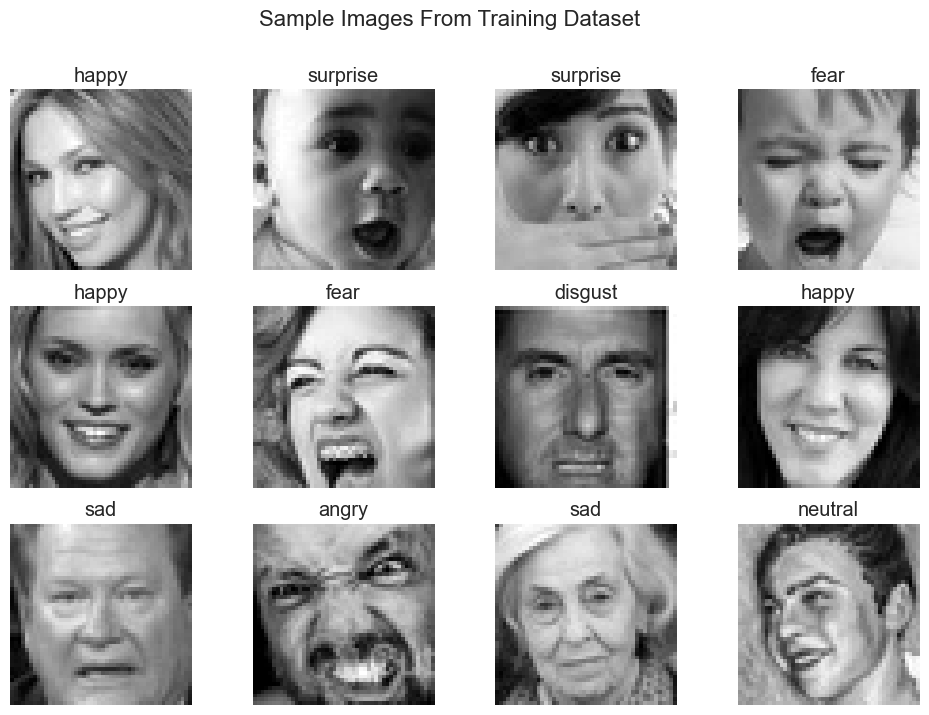

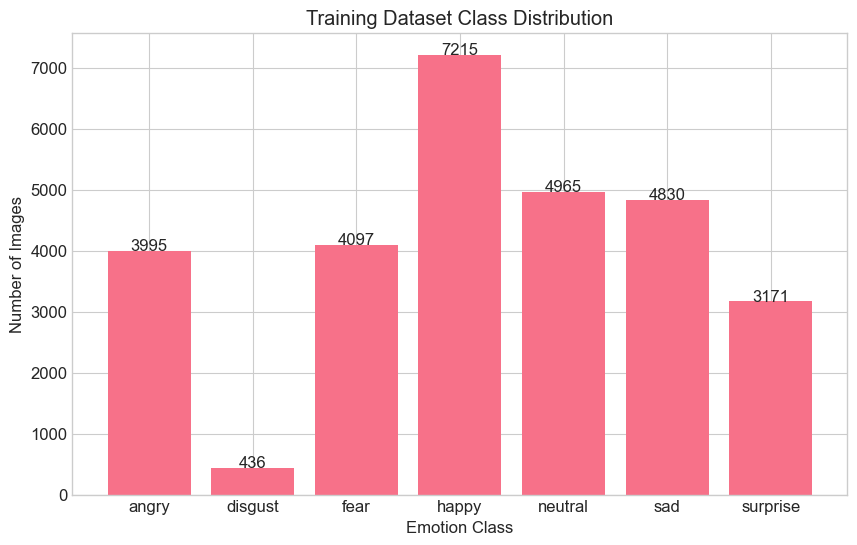

✅ Visualization complete


In [4]:
# ============================================================
# CELL 4: VISUALIZE DATASET (Images + Class Distribution)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

print("📊 Visualizing Dataset")
print("=" * 50)

# ---- Show sample images ----
plt.figure(figsize=(12,8))

for images, labels in train_dataset.take(1):
    
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Images From Training Dataset", fontsize=16)
plt.show()


# ---- Class distribution ----
train_dir = "dataset/train"

class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(10,6))

bars = plt.bar(class_counts.keys(), class_counts.values())

plt.title("Training Dataset Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 5,
             f"{height}",
             ha='center')

plt.show()

print("✅ Visualization complete")

In [5]:
# ============================================================
# CELL 5: BUILD CNN MODEL
# ============================================================

from tensorflow.keras import layers, models

print("🧠 Building CNN Model")
print("=" * 50)

model = models.Sequential([

    # Normalize pixels
    layers.Rescaling(1./255, input_shape=(48,48,1)),

    # Convolution Block 1
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Dense layers
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    # Output layer (7 emotions)
    layers.Dense(7, activation="softmax")

])

model.summary()

print("\n✅ CNN Model Created Successfully")

🧠 Building CNN Model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)


✅ CNN Model Created Successfully


In [6]:
# ============================================================
# CELL 6: TRAIN CNN MODEL
# ============================================================

print("🚀 Training CNN Model...")
print("-" * 40)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15
)

print("\n✅ Training Complete")

🚀 Training CNN Model...
----------------------------------------
Epoch 1/15


898/898 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.3206 - loss: 1.6887 - val_accuracy: 0.4110 - val_loss: 1.5110
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.4476 - loss: 1.4384 - val_accuracy: 0.4759 - val_loss: 1.3603
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.4972 - loss: 1.3183 - val_accuracy: 0.4992 - val_loss: 1.2847
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - accuracy: 0.5307 - loss: 1.2404 - val_accuracy: 0.5185 - val_loss: 1.2414
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 54s 60ms/step - accuracy: 0.5537 - loss: 1.1775 - val_accuracy: 0.5396 - val_loss: 1.2041
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 48s 53ms/step - accuracy: 0.5761 - loss: 1.1163 - val_accuracy: 0.5435 - val_loss: 1.2043
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.5971 - loss: 1.0649 - val_accuracy: 0.5500 - val_loss: 1.1923
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.6170 - loss: 1.0118 - val_accur

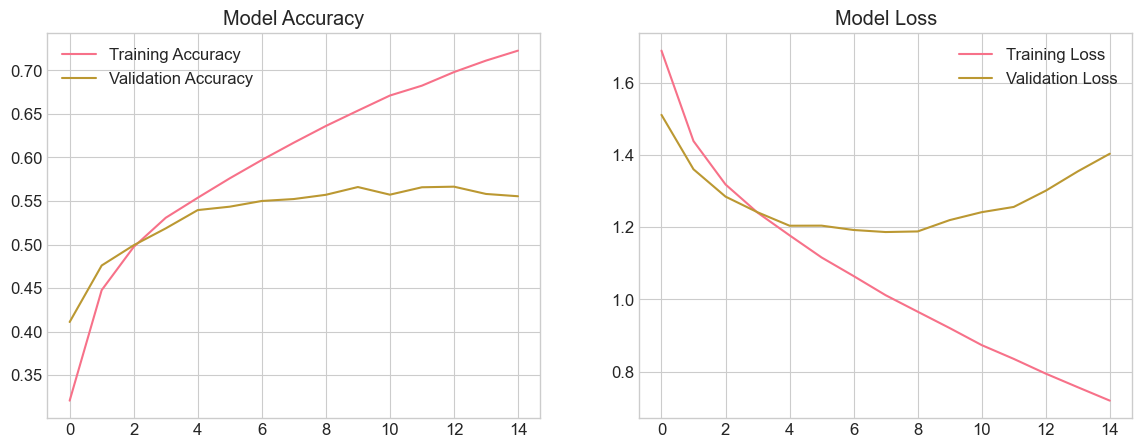

✅ Training graphs generated


In [7]:
# ============================================================
# CELL 7A: TRAINING PERFORMANCE
# ============================================================

import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Accuracy
axes[0].plot(epochs, acc, label="Training Accuracy")
axes[0].plot(epochs, val_acc, label="Validation Accuracy")
axes[0].set_title("Model Accuracy")
axes[0].legend()

# Loss
axes[1].plot(epochs, loss, label="Training Loss")
axes[1].plot(epochs, val_loss, label="Validation Loss")
axes[1].set_title("Model Loss")
axes[1].legend()

plt.show()

print("✅ Training graphs generated")

In [16]:
# ============================================================
# Save model for Streamlit (app.py) — use SavedModel for compatibility
# Run this cell once after training so the web app finds the model
# Save to directory 'emotion_model' (no .keras) = TensorFlow SavedModel (avoids Keras version mismatch)
# ============================================================
import os
save_dir = os.path.join(os.getcwd(), "emotion_model")
model.export(save_dir)
print("Model saved to:", os.path.abspath(save_dir))
print("From the same project folder run: streamlit run app.py")

INFO:tensorflow:Assets written to: c:\XXX\yourbuddy\emotion_model\assets


INFO:tensorflow:Assets written to: c:\XXX\yourbuddy\emotion_model\assets


Saved artifact at 'c:\XXX\yourbuddy\emotion_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2332459513232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332459513424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332459515344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332459514576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332459514960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332459515728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332459515536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332459513808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332459513616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2332487975952: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model saved to: c:\XXX\y

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/

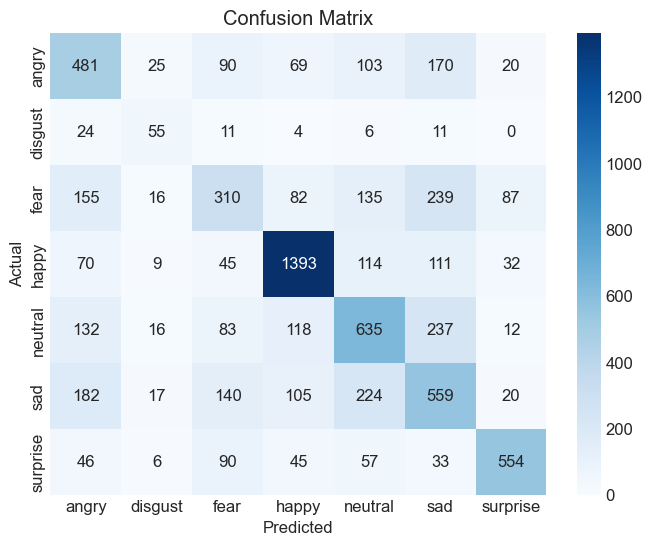

In [10]:
# ============================================================
# CELL 7B: CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    
    predictions = model.predict(images)
    preds = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [11]:
# ============================================================
# CELL 9: FINAL RESULTS SUMMARY
# ============================================================

loss, accuracy = model.evaluate(test_dataset)

print("\n" + "="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

print("\nEmotion Classes:")
for i, name in enumerate(class_names):
    print(f"{i} → {name}")

print("\n🎓 Project Complete")

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5554 - loss: 1.4034

FINAL MODEL PERFORMANCE
Test Accuracy: 0.5554
Test Loss: 1.4034

Emotion Classes:
0 → angry
1 → disgust
2 → fear
3 → happy
4 → neutral
5 → sad
6 → surprise

🎓 Project Complete


🔍 Running Grad-CAM XAI analysis...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


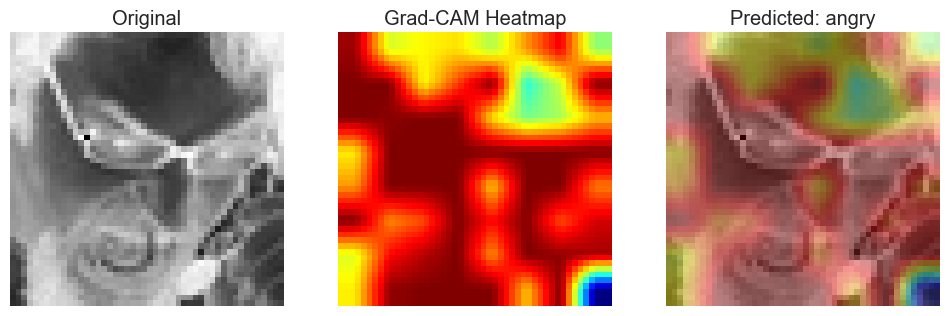

✅ Grad-CAM explanation generated


In [12]:
# ============================================================
# CELL 10: XAI USING GRAD-CAM (FIXED)
# ============================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("🔍 Running Grad-CAM XAI analysis...")
print("="*50)

# Ensure model graph exists
model.predict(np.zeros((1,48,48,1)))

last_conv_layer_name = "conv2d_2"


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Build a new graph from the same layers, and capture the conv output
    # *in that graph* so both outputs belong to the same forward pass.
    inputs = tf.keras.Input(shape=(48, 48, 1))
    x = inputs
    conv_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x  # same graph as x

    grad_model = tf.keras.models.Model(
        inputs=inputs,
        outputs=[conv_output, x]  # both from same graph
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy(), pred_index
# Get one test image
for images, labels in test_dataset.take(1):

    img = images[0].numpy()
    label = labels[0].numpy()

    img_array = np.expand_dims(img, axis=0)

    heatmap, pred_index = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    break


# Resize heatmap
heatmap = cv2.resize(heatmap, (48,48))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Original image
img_rgb = np.uint8(img.squeeze()*255)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)

# Overlay
superimposed_img = cv2.addWeighted(img_rgb, 0.6, heatmap, 0.4, 0)


# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(superimposed_img)
plt.title(f"Predicted: {class_names[pred_index]}")
plt.axis("off")

plt.show()

print("✅ Grad-CAM explanation generated")

In [13]:
# ============================================================
# CELL 11: EXPLAINABLE CLINICAL REPORT GENERATOR (FIXED)
# ============================================================

import numpy as np
import datetime

def generate_explainable_report(image, model, class_names, student_id="Student_001"):
    img_array = np.expand_dims(image, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    pred_index = np.argmax(predictions)
    confidence = float(predictions[pred_index])

    emotion = class_names[pred_index].strip().lower()

    # Top 3 predictions
    top3_idx = predictions.argsort()[-3:][::-1]
    top3 = [(class_names[i], float(predictions[i])) for i in top3_idx]

    # Explanation dictionary
    emotion_reasoning = {
        "angry": [
            "Eyebrow contraction detected, suggesting a frowning pattern",
            "Mouth region shows tension consistent with anger/frustration",
            "Overall facial muscle tightness appears higher than neutral expressions"
        ],
        "sad": [
            "Mouth curvature appears reduced or downward",
            "Eye region appears less activated than positive expressions",
            "Facial expression looks less dynamic, which can align with sadness"
        ],
        "fear": [
            "Eye region appears widened compared with neutral expressions",
            "Eyebrow shape suggests raised tension",
            "Facial pattern indicates alertness or discomfort"
        ],
        "happy": [
            "Mouth corners appear raised, suggesting a smile pattern",
            "Cheek region appears more active",
            "Overall expression is more relaxed and positive"
        ],
        "neutral": [
            "Facial muscles appear balanced without a strong emotional signal",
            "No dominant activation in mouth or eyebrow regions",
            "Expression is relatively stable and non-exaggerated"
        ],
        "surprise": [
            "Eye region appears widened",
            "Eyebrows may be raised",
            "Expression suggests a sudden emotional response"
        ],
        "disgust": [
            "Upper mouth region appears tense",
            "Facial contraction suggests aversion",
            "Expression differs from neutral with localized tension"
        ]
    }

    observed_patterns = emotion_reasoning.get(
        emotion,
        ["The model detected a general facial pattern associated with this class."]
    )

    if confidence >= 0.75:
        confidence_note = "High confidence prediction"
    elif confidence >= 0.50:
        confidence_note = "Moderate confidence prediction"
    else:
        confidence_note = "Low confidence prediction; the model is somewhat uncertain"

    # Optional mental-health style interpretation
    interpretation_map = {
        "sad": "This may reflect low mood or depressive affect.",
        "fear": "This may reflect anxiety, worry, or discomfort.",
        "angry": "This may reflect frustration, stress, or emotional tension.",
        "neutral": "This suggests no strong visible emotional activation at this moment.",
        "happy": "This suggests a positive visible emotional state.",
        "surprise": "This suggests a brief reactive emotional state.",
        "disgust": "This suggests a negative affective reaction."
    }

    interpretation = interpretation_map.get(
        emotion,
        "This reflects the model's detected emotional class."
    )

    lines = []
    lines.append("=" * 66)
    lines.append("AI-ASSISTED MENTAL HEALTH SCREENING REPORT")
    lines.append("=" * 66)
    lines.append("")
    lines.append(f"Student ID: {student_id}")
    lines.append(f"Analysis Time: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
    lines.append("")
    lines.append("-" * 63)
    lines.append("MODEL PREDICTION")
    lines.append("-" * 63)
    lines.append("")
    lines.append(f"Primary Emotion Detected: {emotion.upper()}")
    lines.append(f"Confidence Score: {confidence:.2%}")
    lines.append(f"Interpretation: {confidence_note}")
    lines.append("")
    lines.append("Model also considered:")
    lines.append("")

    for e, p in top3:
        lines.append(f"  • {e.capitalize():10s} : {p:.2%}")

    lines.append("")
    lines.append("-" * 63)
    lines.append("WHY THE MODEL MADE THIS DECISION")
    lines.append("-" * 63)
    lines.append("")
    lines.append("The CNN analyzed these visible facial regions:")
    lines.append("  • Eye region")
    lines.append("  • Eyebrow shape/tension")
    lines.append("  • Mouth curvature")
    lines.append("  • Overall facial muscle activation")
    lines.append("")
    lines.append("Key visual patterns observed:")

    for obs in observed_patterns:
        lines.append(f"  • {obs}")

    lines.append("")
    lines.append("-" * 63)
    lines.append("MENTAL HEALTH INTERPRETATION")
    lines.append("-" * 63)
    lines.append("")
    lines.append(interpretation)
    lines.append("")
    lines.append("This is not a diagnosis. It is an AI-assisted emotional screening result.")
    lines.append("")
    lines.append("-" * 63)
    lines.append("DISCLAIMER")
    lines.append("-" * 63)
    lines.append("")
    lines.append("This system provides AI-assisted screening only.")
    lines.append("Final assessment must be performed by qualified mental health professionals.")
    lines.append("")
    lines.append("=" * 66)

    return "\n".join(lines)

In [38]:
for images, labels in test_dataset.take(1):
    img = images[0].numpy()

    report = generate_explainable_report(
        img,
        model,
        class_names,
        "Student_A_001"
    )

    with open("clinical_report.txt", "w", encoding="utf-8") as f:
        f.write(report)

    print("Full report saved to clinical_report.txt")
    break

Full report saved to clinical_report.txt
